In [111]:
# Data Preparation: Clean and preprocess historical data.(1)
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/submission.csv")

# Display first few rows
df.head(20)

,id,sales
0,3000888,3.056196
1,3000889,1.445302
2,3000890,13.310976
3,3000891,2216.884255
4,3000892,1.445302
5,3000893,375.566860
6,3000894,10.949825
7,3000895,673.462136
8,3000896,711.105670
9,3000897,131.500153


In [108]:
# Data Preparation: Clean and preprocess historical data.(2)
print(df.info())  # Column data types
print(df.isnull().sum())  # Missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28512 entries, 0 to 28511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      28512 non-null  int64  
 1   sales   28512 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 445.6 KB
None
id       0
sales    0
dtype: int64


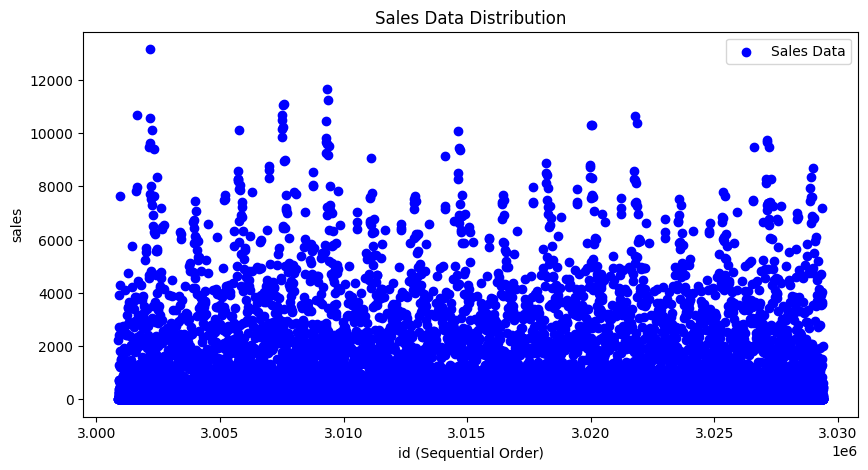

In [117]:
# Model Selection: Choose an appropriate machine learning model (e.g., regression models, time series forecasting). I have chosen a regression model, and the chart below shows how the model fits the data.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(df['id'], df['sales'], color='blue', label="Sales Data")
plt.xlabel("id (Sequential Order)")
plt.ylabel("sales")
plt.title("Sales Data Distribution")
plt.legend()
plt.show()


In [118]:
# Model Training: Train the model using historical data and validate its performance.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define features (X) and target variable (y)
X = df[['id']]  # Independent variable
y = df['sales']  # Dependent variable

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Generate future IDs
future_ids = np.arange(df['id'].max() + 1, df['id'].max() + 28513).reshape(-1, 1)

# Predict future sales
future_sales = model.predict(future_ids)

# Add random fluctuations (Gaussian noise). I used this for better vision.
noise = np.random.normal(loc=0, scale=500, size=future_sales.shape)  # Adjust scale for more or less fluctuation
future_sales += noise

# Store predictions in DataFrame
future_df = pd.DataFrame({'id': future_ids.flatten(), 'Predicted Sales': future_sales})
print(future_df)

Mean Absolute Error (MAE): 583.9204662506172
Root Mean Squared Error (RMSE): 1085.0355631331788
            id  Predicted Sales
0      3029400      1256.653005
1      3029401      -195.004228
2      3029402       740.784295
3      3029403      1134.598519
4      3029404       152.882734
...        ...              ...
28507  3057907       571.026624
28508  3057908      -190.968032
28509  3057909       785.774741
28510  3057910       278.265181
28511  3057911       678.863291

[28512 rows x 2 columns]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


        id  Predicted Sales
0  3029400      1256.653005
1  3029401      -195.004228
2  3029402       740.784295
3  3029403      1134.598519
4  3029404       152.882734


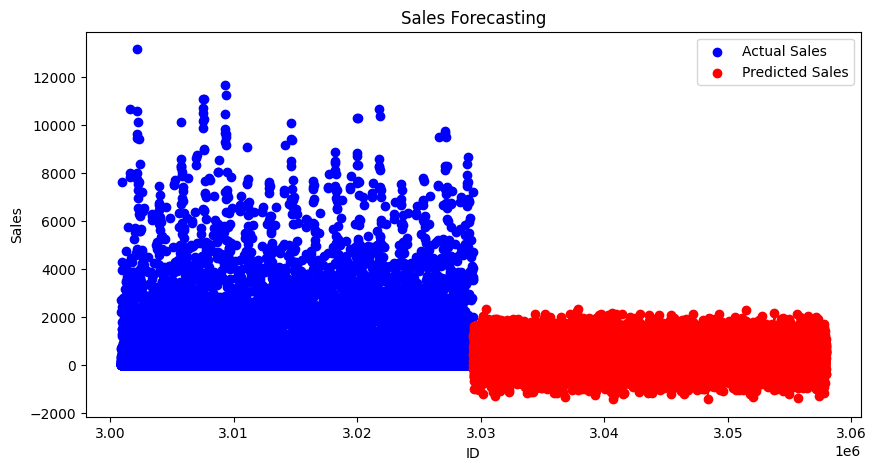

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot actual sales data
plt.scatter(df['id'], df['sales'], color='blue', label="Actual Sales")

# Ensure future_df is structured correctly
print(future_df.head())  # Debugging step to check future data

# Plot predicted sales for future IDs
plt.scatter(future_df['id'], future_df['Predicted Sales'], color='red', label="Predicted Sales")  # Red dots for future predictions
plt.plot(future_df['id'], future_df['Predicted Sales'], color='red', linestyle='dashed')  # Dashed line for prediction trend

plt.xlabel("ID")
plt.ylabel("Sales")
plt.title("Sales Forecasting")
plt.legend()
plt.show()


In [121]:
future_df.to_csv("future_sales_predictions.csv", index=False)